In [1]:
import numpy as np
import matplotlib.pyplot as plt

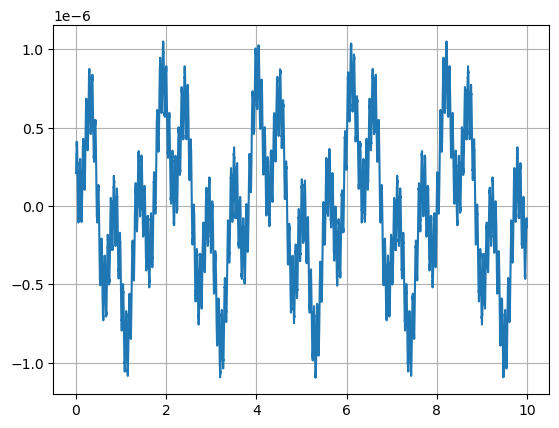

In [2]:
# define a simple 1 DoF system
amps = np.array([0.5,0.4,0.02,0.2])*1e-6
freqs = np.array([3,12,740,92])
phases = np.array([0,125,69,250])

dt = 1e-4
tvec = np.arange(1e+5)*dt

plant = lambda t: amps[0]*np.cos(t*freqs[0]+phases[0]/180*np.pi) + amps[1]*np.cos(t*freqs[1]+phases[1]/180*np.pi) + amps[2]*np.cos(t*freqs[2]+phases[2]/180*np.pi) + amps[3]*np.cos(t*freqs[3]+phases[3]/180*np.pi)
y = plant(tvec)

plt.figure()
plt.plot(tvec,y)
plt.grid()

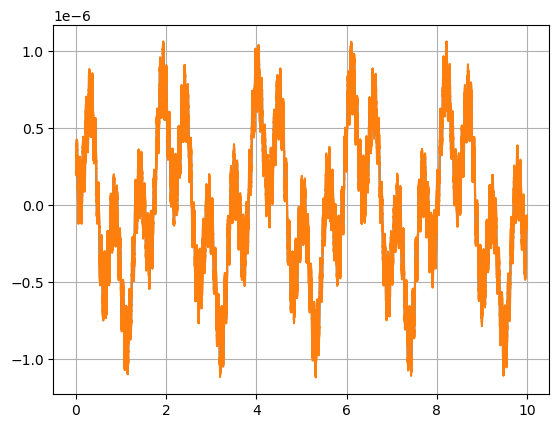

In [3]:
# simple controller with noise and n-steps delay
sigma = 1e-8
y_meas = y + np.random.randn(len(y))*sigma

plt.figure()
plt.plot(tvec,y)
plt.plot(tvec,y_meas)
plt.grid()

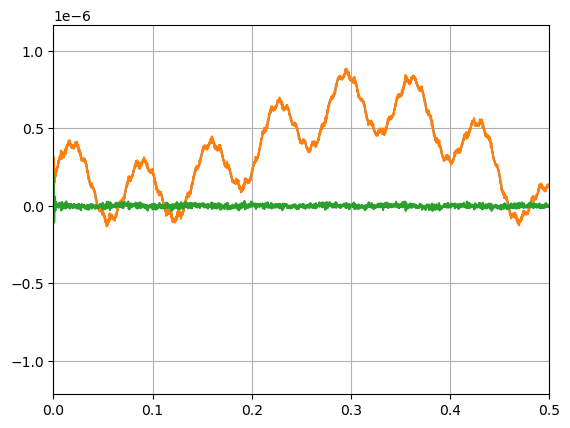

In [4]:
# actuator with n steps delay
N = len(y)
cmd_hist = np.zeros(N)
cmd = 0
int_gain = 0.4
delay_steps = 3

for j in range(N):
    if j >= delay_steps:
        meas = y[j] - cmd_hist[j-delay_steps] + np.random.randn(1)*sigma
    else:
        meas = y[j] + np.random.randn(1)*sigma
    cmd += int_gain*meas[0]
    cmd_hist[j] = cmd

res = y.copy()
res[delay_steps:] -= cmd_hist[:-delay_steps]

plt.figure()
plt.plot(tvec,y)
plt.plot(tvec,cmd_hist)
plt.plot(tvec,res)
plt.xlim([0,0.5])
plt.grid()

In [5]:
# Predictor controller, M = 1, N = 4
Mf = 3 # future steps
Np = 4 # past states
theta = np.ones([Mf,2*Np + Mf]) # parameters
P = np.eye(2*Np+Mf)*1e+9

gamma = 1.0 # forgetting factor
lreg = 1e-3

In [6]:

CMAT = lambda A,B,C,lreg: -np.linalg.pinv(C.T @ C + lreg*np.eye(len(C))) @ np.vstack([A.T @ C, B.T @ C]).T

In [7]:
def ddspc_step(y,phi,theta,P,gamma=0.999,lreg=1e-3):
    K = P @ phi / (gamma + phi.T @ P @ phi)
    err = y - theta @ phi[:,0]
    theta += np.outer(err,K.T)
    P = 1/gamma * (P - K @ phi.T @ P)

    A = theta[:,:Np]
    B = theta[:,Np:2*Np]
    C = theta[:,2*Np:]
    Cmat = CMAT(A,B,C,lreg)
    cmds = Cmat @ phi[:2*Np]
    return cmds[:,0], theta, P

In [8]:
# Run DDSPC controller
past_y = np.zeros(Np)
past_u = np.zeros(Np)
future_u = np.zeros(Mf)
cmd_hist = np.zeros(len(y))
sigma = 0
meas = y[:Mf] 
bootstrap = 100
cmd = 0
n = 4

for j in range(n*bootstrap):
    phi = np.concatenate([past_y, past_u, future_u]).reshape([2*Np+Mf,1])
    future_u, theta, P = ddspc_step(meas, phi, theta, P)
    
    if j >= delay_steps:
        y_meas = y[j] - cmd_hist[j-delay_steps] + np.random.randn()*sigma
    else:
        y_meas = y[j] + np.random.randn()*sigma
    if j > bootstrap:
        cmd = future_u[0]
    else:
        cmd += int_gain*y_meas
    cmd_hist[j] = cmd
    # update past
    past_y = np.roll(past_y, -1)
    past_y[-1] = y_meas
    past_u = np.roll(past_u, -1)
    past_u[-1] = cmd

In [9]:
print(theta)

[[1.03796696 1.03578672 1.03303312 1.03303057 0.98700175 0.98429908
  0.98235917 0.9826931  0.96947769 0.96947769 0.96947769]
 [1.03795994 1.03577969 1.03302606 1.03302347 0.98700426 0.9843016
  0.9823617  0.98269562 0.96948407 0.96948407 0.96948407]
 [1.03794997 1.03576971 1.03301604 1.0330134  0.98700783 0.98430519
  0.98236527 0.98269919 0.96949312 0.96949312 0.96949312]]


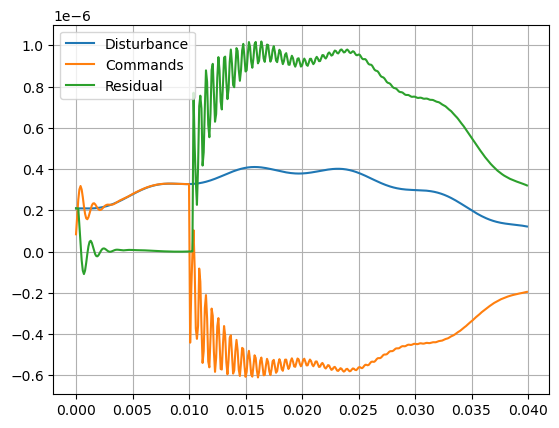

In [10]:
res = y.copy()
res[delay_steps:n*bootstrap] -= cmd_hist[:n*bootstrap-delay_steps]

plt.figure()
plt.plot(tvec[:n*bootstrap],y[:n*bootstrap], label='Disturbance')
plt.plot(tvec[:n*bootstrap],cmd_hist[:n*bootstrap], label='Commands')
plt.plot(tvec[:n*bootstrap],res[:n*bootstrap], label='Residual')
# plt.xlim([0,0.5])
plt.legend()
plt.grid()